# Experiment Analysis — NetLogo BehaviorSpace

Six experiments across two themes: **coaching output** (Exp 1–3) and **strategic adaptation** (Exp 4–6).

| # | Experiment | Varying Parameters | ~Runs |
|---|---|---|---|
| 1 | coaching-output-exp1 | `coaching-skill-increase`, `working-skill-increase`, `max-coaching-rate` | 180 |
| 2 | coaching-output-exp2 | `working-turnover-increase`, `coaching-turnover-decrease`, `leaving-threshold` | 144 |
| 3 | coaching-output-exp3 | `skill-decay-threshold`, `skill-decay-rate` | 25 |
| 4 | strategy-exp1 | `strategy-review-interval`, `working-turnover-increase`, `coaching-turnover-decrease`, `leaving-threshold` | 250 |
| 5 | strategy-exp2 | `strategy-review-interval`, `headcount-variance`, `hiring-threshold-variance`, `vacancy-rate-cutoff` | 270 |
| 6 | strategy-exp3 | `strategy-review-interval`, `coaching-skill-ceiling`, `diminishing-returns-coaching` | 100 |

**All runs: 8 000 ticks (80 simulated years). Metrics sampled every 10 ticks.**

**Primary outcomes extracted at final tick (t = 8 000):**
- `cum_rev_mean` — mean cumulative revenue across companies
- `skill_mean` — market-wide mean developer skill
- `unemployment_rate` — fraction of developers unemployed
- `propensity_to_leave_mean` — average turnover propensity
- `rev_market_std` — cross-company revenue std (market inequality)


In [30]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
# Set RESULTS_DIR to the folder containing the downloaded experiment CSVs.
# run_experiments.sh puts results in  results/<timestamp>/
# The cell below auto-selects the most recent subfolder.

import glob as _glob, os as _os

RESULTS_DIR = "results"
_subdirs = sorted([d for d in _glob.glob(f"{RESULTS_DIR}/*/") if _os.path.isdir(d)])
LATEST = _subdirs[-1].rstrip("/") if _subdirs else RESULTS_DIR
print(f"Results folder : {LATEST}")

# ── BURN-IN FILTER ─────────────────────────────────────────────────────────────
# Set SKIP_BURNIN = True to exclude the first BURNIN_TICKS ticks from all CSVs.
# For load_experiment() this means only ticks >= BURNIN_TICKS are considered
# when selecting the final-state row per run.
# For load_timeseries() rows with tick < BURNIN_TICKS are dropped entirely.
# Toggle this off by setting SKIP_BURNIN = False.
SKIP_BURNIN  = True
BURNIN_TICKS = 1000
print(f"Burn-in filter : {'ENABLED — ignoring first ' + str(BURNIN_TICKS) + ' ticks' if SKIP_BURNIN else 'DISABLED'}")

EXP_PATHS = {
    "coaching-output-exp1": f"{LATEST}/simulation coaching-output-exp1-table.csv",
    "coaching-output-exp2": f"{LATEST}/simulation coaching-output-exp2-spreadsheet.csv",
    "coaching-output-exp3": f"{LATEST}/simulation coaching-output-exp3-spreadsheet.csv",
    "strategy-exp1":        f"{LATEST}/simulation strategy-exp1-table.csv",
    "strategy-exp2":        f"{LATEST}/simulation strategy-exp2-table.csv",
    "strategy-exp3":        f"{LATEST}/simulation strategy-exp3-table.csv",
}

# Varying parameters per experiment (exact names from NetLogo model)
EXP_PARAMS = {
    "coaching-output-exp1": ["coaching-skill-increase", "working-skill-increase", "max-coaching-rate"],
    "coaching-output-exp2": ["working-turnover-increase", "coaching-turnover-decrease", "leaving-threshold"],
    "coaching-output-exp3": ["skill-decay-threshold", "skill-decay-rate"],
    "strategy-exp1":        ["strategy-review-interval", "working-turnover-increase", "coaching-turnover-decrease", "leaving-threshold"],
    "strategy-exp2":        ["strategy-review-interval", "headcount-variance", "hiring-threshold-variance", "vacancy-rate-cutoff"],
    "strategy-exp3":        ["strategy-review-interval", "coaching-skill-ceiling", "diminishing-returns-coaching"],
}

print("\nFile check:")
for exp, path in EXP_PATHS.items():
    status = "OK" if _os.path.exists(path) else "MISSING"
    print(f"  [{status}]  {exp}")


Results folder : results
Burn-in filter : ENABLED — ignoring first 1000 ticks

File check:
  [OK]  coaching-output-exp1
  [OK]  coaching-output-exp2
  [OK]  coaching-output-exp3
  [OK]  strategy-exp1
  [OK]  strategy-exp2
  [OK]  strategy-exp3


## 1 · Imports


In [31]:
import re
import ast
import csv
import io
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=RuntimeWarning)


## 2 · Shared helpers


In [32]:
# ── Same as sensitivity_analysis template ─────────────────────────────────────

def parse_netlogo_list(raw: str) -> list:
    """Convert a NetLogo list string '[1 2 3]' or '[[1 2] [3 4]]' to a Python list."""
    cleaned = re.sub(r"\s+", ", ", raw.strip()).replace("[, ", "[").replace(", ]", "]")
    return ast.literal_eval(cleaned)


def eta_squared(groups: list) -> float:
    """One-way eta-squared (η²).  < 0.06 weak | 0.06-0.14 moderate | > 0.14 strong."""
    all_vals   = np.concatenate(groups)
    grand_mean = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total   = sum((v - grand_mean) ** 2 for v in all_vals)
    return ss_between / ss_total if ss_total > 0 else 0.0


In [33]:

# ── Format detection ──────────────────────────────────────────────────────────

def _detect_format(all_rows):
    """
    Spreadsheet: has '[all run data]' as the first cell of a row — definitive marker.
    Table:       has '[run number]' as the first cell but NO '[all run data]' anywhere.

    BehaviorSpace spreadsheets also contain a '[run number]' header row listing
    run indices, so we must check for '[all run data]' first.

    We scan ALL rows (file is already in memory) — the marker can appear beyond
    row 120 when the header section lists many global parameters.
    """
    for row in all_rows:
        if row and '[all run data]' in str(row[0]):
            return 'spreadsheet'
    for row in all_rows:
        if row and '[run number]' in str(row[0]):
            return 'table'
    return 'spreadsheet'  # safe default


# ── Shared header parser (spreadsheet only) ───────────────────────────────────

def _extract_params(header_rows, param_names):
    """Scan pre-data header rows and return {param_name: [value_per_run]}."""
    params = {}
    for row in header_rows:
        if not row:
            continue
        name = row[0].strip().strip('"')
        if name in param_names:
            vals = []
            for cell in row[1:]:
                v = cell.strip()
                if not v:
                    continue
                if v.lower() in ('true', 'false'):
                    vals.append(v.lower() == 'true')
                else:
                    try:
                        fv = float(v)
                        vals.append(int(fv) if fv == int(fv) else fv)
                    except ValueError:
                        vals.append(v)
            if vals:
                params[name] = vals
    return params


def _parse_cell(v):
    """Parse a single CSV cell to bool / int / float / str."""
    v = v.strip()
    if v.lower() in ('true', 'false'):
        return v.lower() == 'true'
    try:
        fv = float(v)
        return int(fv) if fv == int(fv) else fv
    except ValueError:
        return v


def _parse_metrics_row(row, c_dep, c_rev, c_skill, c_unemp):
    """Extract metric dict from one data row. Column indices may be None."""
    rec = {}
    if c_dep is not None and len(row) > c_dep and row[c_dep].strip():
        try:
            dep = parse_netlogo_list(row[c_dep])
            rec['cum_rev_mean']       = float(np.mean(dep[0]))
            rec['coaching_rate_mean'] = float(np.mean(dep[1]))
            rec['vacancies_mean']     = float(np.mean(dep[2]))
            if len(dep) > 3:
                rec['propensity_mean'] = float(np.mean(dep[3]))
        except Exception:
            pass
    if c_rev is not None and len(row) > c_rev and row[c_rev].strip():
        try:
            rd = parse_netlogo_list(row[c_rev])
            rec['rev_market_mean']   = float(rd[0])
            rec['rev_market_std']    = float(rd[1])
            rec['rev_market_median'] = float(rd[2])
        except Exception:
            pass
    if c_skill is not None and len(row) > c_skill and row[c_skill].strip():
        try:
            sd = parse_netlogo_list(row[c_skill])
            rec['skill_mean']   = float(sd[0])
            rec['skill_std']    = float(sd[1])
            rec['skill_median'] = float(sd[2])
        except Exception:
            pass
    if c_unemp is not None and len(row) > c_unemp and row[c_unemp].strip():
        try:
            rec['unemployment_rate'] = float(row[c_unemp])
        except Exception:
            pass
    return rec


# ── TABLE format (long: one row per run×tick) ─────────────────────────────────
#
# Varying parameter values appear as extra DATA columns, e.g.:
#   [run number], [step], coaching-skill-increase, working-skill-increase, ..., dep-vars, ...

def _col(col_names, key):
    """Column index by case-insensitive substring match (hyphens/spaces stripped)."""
    key_n = key.lower().replace('-', '').replace(' ', '')
    for j, c in enumerate(col_names):
        if key_n in c.lower().replace('-', '').replace(' ', ''):
            return j
    return None


def _table_cols(all_rows):
    idx = next(i for i, row in enumerate(all_rows) if row and '[run number]' in str(row[0]))
    col_names = [c.strip().strip('"') for c in all_rows[idx]]
    return idx, col_names


def _load_table_final(all_rows, param_names, burn_in=0):
    data_header_idx, col_names = _table_cols(all_rows)
    header_rows = all_rows[:data_header_idx]
    data_rows   = all_rows[data_header_idx + 1:]

    param_col_idx = {p: _col(col_names, p) for p in param_names
                     if _col(col_names, p) is not None}
    header_params = _extract_params(header_rows, param_names)
    missing = set(param_names) - set(param_col_idx) - set(header_params)
    if missing:
        print(f"  Warning: params not found in columns or header: {missing}")
    print(f"  Params from data columns : {sorted(param_col_idx)}")
    print(f"  Params from header rows  : {sorted(header_params)}")

    c_run   = _col(col_names, 'run number')
    c_step  = _col(col_names, 'step')
    c_dep   = _col(col_names, 'dependent-variables') or _col(col_names, 'dependent')
    c_rev   = _col(col_names, 'revenue-distribution') or _col(col_names, 'revenuedistribution')
    c_skill = _col(col_names, 'skill-distribution')  or _col(col_names, 'skilldistribution')
    c_unemp = _col(col_names, 'unemployment-rate')   or _col(col_names, 'unemployment')

    best = {}
    for row in data_rows:
        try:
            rid  = int(row[c_run])
            tick = int(row[c_step])
        except (ValueError, TypeError, IndexError):
            continue
        if tick < burn_in:
            continue
        if rid not in best or tick > best[rid][0]:
            best[rid] = (tick, row)

    records = []
    for rid, (tick, row) in sorted(best.items()):
        rec = {'run': rid, 'final_tick': tick}
        for pname in param_names:
            if pname in param_col_idx:
                cidx = param_col_idx[pname]
                rec[pname] = _parse_cell(row[cidx]) if len(row) > cidx else None
            elif pname in header_params:
                lst = header_params[pname]
                rec[pname] = lst[rid - 1] if rid <= len(lst) else None
            else:
                rec[pname] = None
        rec.update(_parse_metrics_row(row, c_dep, c_rev, c_skill, c_unemp))
        records.append(rec)
    return records


def _load_table_ts(all_rows, param_names, run_ids=None, burn_in=0):
    data_header_idx, col_names = _table_cols(all_rows)
    header_rows = all_rows[:data_header_idx]
    data_rows   = all_rows[data_header_idx + 1:]

    param_col_idx = {p: _col(col_names, p) for p in param_names
                     if _col(col_names, p) is not None}
    header_params = _extract_params(header_rows, param_names)

    c_run   = _col(col_names, 'run number')
    c_step  = _col(col_names, 'step')
    c_dep   = _col(col_names, 'dependent-variables') or _col(col_names, 'dependent')
    c_rev   = _col(col_names, 'revenue-distribution') or _col(col_names, 'revenuedistribution')
    c_skill = _col(col_names, 'skill-distribution')  or _col(col_names, 'skilldistribution')
    c_unemp = _col(col_names, 'unemployment-rate')   or _col(col_names, 'unemployment')

    records = []
    for row in data_rows:
        try:
            rid  = int(row[c_run])
            tick = int(row[c_step])
        except (ValueError, TypeError, IndexError):
            continue
        if run_ids and rid not in run_ids:
            continue
        if tick < burn_in:
            continue
        rec = {'run': rid, 'tick': tick}
        for pname in param_names:
            if pname in param_col_idx:
                cidx = param_col_idx[pname]
                rec[pname] = _parse_cell(row[cidx]) if len(row) > cidx else None
            elif pname in header_params:
                lst = header_params[pname]
                rec[pname] = lst[rid - 1] if rid <= len(lst) else None
            else:
                rec[pname] = None
        rec.update(_parse_metrics_row(row, c_dep, c_rev, c_skill, c_unemp))
        records.append(rec)
    return records


# ── SPREADSHEET format (wide: column block per run) ───────────────────────────

def _find_data_boundary(all_rows):
    for i, row in enumerate(all_rows):
        if row and '[all run data]' in str(row[0]):
            non_empty = [c.strip().strip('"') for c in row[1:] if c.strip()]
            try:
                second_step = next(j for j, c in enumerate(non_empty) if j > 0 and '[step]' in c)
                n_cols = second_step
            except StopIteration:
                n_cols = len(non_empty)
            metric_names = non_empty[1:n_cols]
            return i, n_cols, metric_names
    raise ValueError("Cannot find '[all run data]' header in CSV")


def _ss_col(run, metric_key, n_cols_per_run, metric_names):
    base = 1 + (run - 1) * n_cols_per_run
    if metric_key == 'step':
        return base
    key_n = metric_key.lower().replace('-', '')
    for j, m in enumerate(metric_names):
        if key_n in m.lower().replace('-', ''):
            return base + 1 + j
    return None


def _load_spreadsheet_final(all_rows, param_names, burn_in=0):
    data_header_idx, n_cols, metric_names = _find_data_boundary(all_rows)
    header_rows = all_rows[:data_header_idx]
    data_rows   = all_rows[data_header_idx + 1:]
    params      = _extract_params(header_rows, param_names)
    n_runs      = max(len(v) for v in params.values()) if params else 0

    missing = set(param_names) - set(params)
    if missing:
        print(f"  Warning: params not found: {missing}")
    print(f"  Runs: {n_runs}  |  Metrics: {metric_names}")

    records = []
    for r in range(1, n_runs + 1):
        c_step  = _ss_col(r, 'step',        n_cols, metric_names)
        c_dep   = _ss_col(r, 'dependent',   n_cols, metric_names)
        c_rev   = _ss_col(r, 'revenue-dist',n_cols, metric_names)
        c_skill = _ss_col(r, 'skill-dist',  n_cols, metric_names)
        c_unemp = _ss_col(r, 'unemployment',n_cols, metric_names)

        best_row, best_tick = None, -1
        for row in data_rows:
            if c_step and len(row) > c_step:
                s = row[c_step].strip()
                if s.lstrip('-').isdigit() and int(s) >= burn_in and int(s) > best_tick:
                    best_tick = int(s)
                    best_row  = row
        if best_row is None:
            continue

        rec = {'run': r, 'final_tick': best_tick}
        for pname in param_names:
            lst = params.get(pname, [])
            rec[pname] = lst[r - 1] if r <= len(lst) else None
        rec.update(_parse_metrics_row(best_row, c_dep, c_rev, c_skill, c_unemp))
        records.append(rec)
    return records


def _load_spreadsheet_ts(all_rows, param_names, run_ids=None, burn_in=0):
    data_header_idx, n_cols, metric_names = _find_data_boundary(all_rows)
    header_rows = all_rows[:data_header_idx]
    data_rows   = all_rows[data_header_idx + 1:]
    params      = _extract_params(header_rows, param_names)
    n_runs      = max(len(v) for v in params.values()) if params else 0
    target      = run_ids or list(range(1, n_runs + 1))

    records = []
    for row in data_rows:
        for r in target:
            c_step  = _ss_col(r, 'step',        n_cols, metric_names)
            c_dep   = _ss_col(r, 'dependent',   n_cols, metric_names)
            c_rev   = _ss_col(r, 'revenue-dist',n_cols, metric_names)
            c_skill = _ss_col(r, 'skill-dist',  n_cols, metric_names)
            c_unemp = _ss_col(r, 'unemployment',n_cols, metric_names)
            if not (c_step and len(row) > c_step and row[c_step].strip().lstrip('-').isdigit()):
                continue
            tick = int(row[c_step])
            if tick < burn_in:
                continue
            rec  = {'run': r, 'tick': tick}
            for pname in param_names:
                lst = params.get(pname, [])
                rec[pname] = lst[r - 1] if r <= len(lst) else None
            rec.update(_parse_metrics_row(row, c_dep, c_rev, c_skill, c_unemp))
            records.append(rec)
    return records


# ── Public API — auto-detects format ─────────────────────────────────────────

def load_experiment(csv_path: str, param_names: list) -> pd.DataFrame:
    """
    Load a BehaviorSpace CSV (table OR spreadsheet — auto-detected).

    Table format:  varying params are DATA columns — read per row.
    Spreadsheet:   params are HEADER rows — read once, indexed by run number.
    """
    with open(csv_path, newline='', encoding='utf-8') as f:
        all_rows = list(csv.reader(f))

    fmt = _detect_format(all_rows)
    print(f"  Format: {fmt}")

    burn_in = BURNIN_TICKS if SKIP_BURNIN else 0
    records = (_load_table_final(all_rows, param_names, burn_in=burn_in)
               if fmt == 'table'
               else _load_spreadsheet_final(all_rows, param_names, burn_in=burn_in))

    df = pd.DataFrame(records)
    print(f"  Loaded {len(df)} runs.  Columns: {list(df.columns)}")
    return df


def load_timeseries(csv_path: str, param_names: list, run_ids: list = None) -> pd.DataFrame:
    """
    Load full time series (table OR spreadsheet — auto-detected).
    run_ids: 1-indexed list of runs to load (None = all).
    """
    with open(csv_path, newline='', encoding='utf-8') as f:
        all_rows = list(csv.reader(f))

    fmt = _detect_format(all_rows)
    burn_in = BURNIN_TICKS if SKIP_BURNIN else 0
    records = (_load_table_ts(all_rows, param_names, run_ids, burn_in=burn_in)
               if fmt == 'table'
               else _load_spreadsheet_ts(all_rows, param_names, run_ids, burn_in=burn_in))

    return pd.DataFrame(records)


In [34]:
# ── Shared plot utilities (same viridis palette / DPI as template) ────────────

CMAP = "viridis"

def _fmt(v):
    """Human-readable number for heatmap cell annotations."""
    if abs(v) >= 1e6:  return f"{v/1e6:.1f}M"
    if abs(v) >= 1e3:  return f"{v/1e3:.1f}K"
    return f"{v:.2g}"


def make_heatmap(ax, df, x_param, y_param, metric, title, cmap=CMAP, annotate=True):
    """
    2-parameter heatmap: x_param × y_param → mean(metric).
    Works with any numeric param values.
    """
    pivot = df.groupby([y_param, x_param])[metric].mean().unstack(x_param)
    pivot = pivot.sort_index(ascending=True)  # lower values at bottom
    arr   = pivot.values.astype(float)
    vmin, vmax = np.nanmin(arr), np.nanmax(arr)

    im = ax.imshow(arr, cmap=cmap, aspect='auto', origin='lower',
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.3g}" for v in pivot.columns], rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.3g}" for v in pivot.index], fontsize=8)
    ax.set_xlabel(x_param, fontsize=9)
    ax.set_ylabel(y_param, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_facecolor("#f0f0f0")

    if annotate:
        threshold = (vmin + vmax) / 2
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                v = arr[i, j]
                if not np.isnan(v):
                    color = 'white' if v < threshold else 'black'
                    ax.text(j, i, _fmt(v), ha='center', va='center',
                            fontsize=6, color=color)
    return im


def make_faceted_heatmaps(df, x_param, y_param, facet_param, metrics,
                           metric_labels=None, figsize_per_panel=(4, 3.5)):
    """
    Grid of heatmaps: rows = metrics, cols = facet_param levels.
    Returns figure.
    """
    facet_vals = sorted(df[facet_param].unique())
    n_rows, n_cols = len(metrics), len(facet_vals)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_panel[0]*n_cols, figsize_per_panel[1]*n_rows),
        squeeze=False
    )
    fig.patch.set_facecolor("white")
    labels = metric_labels or metrics

    for row_i, (metric, label) in enumerate(zip(metrics, labels)):
        for col_j, fval in enumerate(facet_vals):
            ax  = axes[row_i][col_j]
            sub = df[df[facet_param] == fval]
            title = f"{label}\n{facet_param}={fval}"
            if metric in sub.columns:
                make_heatmap(ax, sub, x_param, y_param, metric, title)
            else:
                ax.set_title(f"{label} — no data", fontsize=9)
                ax.set_visible(False)
    plt.tight_layout()
    return fig


def make_interaction_plot(ax, df, x_param, group_param, metric,
                           title, n_groups=None, cmap=CMAP):
    """
    Interaction plot: x_param on x-axis, one line per level of group_param.
    Line color encodes group level via cmap.
    """
    group_vals = sorted(df[group_param].unique())
    if n_groups:
        # pick evenly spaced subset
        idx = np.round(np.linspace(0, len(group_vals)-1, n_groups)).astype(int)
        group_vals = [group_vals[i] for i in idx]

    cmap_fn = plt.get_cmap(cmap)
    colors  = [cmap_fn(i / max(len(group_vals)-1, 1)) for i in range(len(group_vals))]

    for gval, color in zip(group_vals, colors):
        sub  = df[df[group_param] == gval].groupby(x_param)[metric].mean()
        ax.plot(sub.index, sub.values, marker='o', markersize=4,
                color=color, label=f"{group_param}={gval:.3g}")

    ax.set_xlabel(x_param, fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_facecolor("#f8f8f8")
    ax.legend(fontsize=7, loc='best', framealpha=0.8)
    ax.grid(axis='y', alpha=0.3)


def make_ts_lines(ax, df_ts, run_ids, df_final, param_names, metric,
                  title, color_top='#d62728', color_low='#1f77b4'):
    """
    Time-series line plot for selected run IDs.
    run_ids[:n//2] plotted in color_top (best), the rest in color_low (worst).
    """
    half = len(run_ids) // 2
    for i, rid in enumerate(run_ids):
        sub = df_ts[df_ts['run'] == rid].sort_values('tick')
        row = df_final[df_final['run'] == rid]
        if row.empty or metric not in sub.columns:
            continue
        label = ', '.join(f"{p}={row[p].values[0]:.3g}" for p in param_names)
        color = color_top if i < half else color_low
        style = '-' if i < half else '--'
        ax.plot(sub['tick'], sub[metric], color=color, alpha=0.75,
                linestyle=style, linewidth=1.2, label=label)

    ax.set_xlabel("Tick", fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_facecolor("#f8f8f8")
    ax.legend(fontsize=6, loc='upper left', framealpha=0.8)
    ax.grid(axis='y', alpha=0.3)


---
## 3 · Coaching Output — Experiment 1: Skill Gains

**Research question:** Under what combination of `coaching-skill-increase`, `working-skill-increase`,
and `max-coaching-rate` does the market achieve the best revenue and skill level?

### Plots produced
| Plot | What to read |
|---|---|
| Faceted heatmaps (revenue + skill) | Each column = one `max-coaching-rate` level. Does the best combo shift as the ceiling increases? |
| Time series (top vs bottom combos) | Do high-coaching strategies win early or only over the long run? |

### Interpretation guide
- **Hot spot moves right/up** as `max-coaching-rate` increases → coaching rate ceiling is a binding constraint; raising it allows more aggressive coaching to pay off.
- **Hot spot stays fixed** across facets → `max-coaching-rate` is irrelevant; the ratio of skill gains alone determines outcome.
- **Revenue and skill hot spots align** → the model rewards skill investment without a revenue penalty.
- **Revenue and skill hot spots diverge** → there is a genuine tradeoff between productivity and growth.
- **Time series**: if top combos only pull ahead after tick ~4000, the benefit is a long-run effect requiring patience.


In [35]:
EXP = "coaching-output-exp1"
PARAMS1 = EXP_PARAMS[EXP]

print(f"Loading {EXP} ...")
df1 = load_experiment(EXP_PATHS[EXP], PARAMS1)
df1.head()


Loading coaching-output-exp1 ...
  Format: table
  Params from data columns : ['coaching-skill-increase', 'max-coaching-rate', 'working-skill-increase']
  Params from header rows  : []
  Loaded 180 runs.  Columns: ['run', 'final_tick', 'coaching-skill-increase', 'working-skill-increase', 'max-coaching-rate', 'cum_rev_mean', 'coaching_rate_mean', 'vacancies_mean', 'propensity_mean', 'rev_market_mean', 'rev_market_std', 'rev_market_median', 'skill_mean', 'skill_std', 'skill_median', 'unemployment_rate']


,run,final_tick,coaching-skill-increase,working-skill-increase,max-coaching-rate,cum_rev_mean,coaching_rate_mean,vacancies_mean,propensity_mean,rev_market_mean,rev_market_std,rev_market_median,skill_mean,skill_std,skill_median,unemployment_rate
0,1,8000,0,0,0,0.0,0.0,0.0,16.181818,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2,8000,20,0,0,0.0,0.0,0.0,17.393939,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,8000,40,0,0,0.0,0.0,0.0,15.858586,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,4,8000,60,0,0,0.0,0.0,0.0,16.585859,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,5,8000,80,0,0,0.0,0.0,0.0,15.686869,0.0,0.0,0.0,NaN,NaN,NaN,NaN


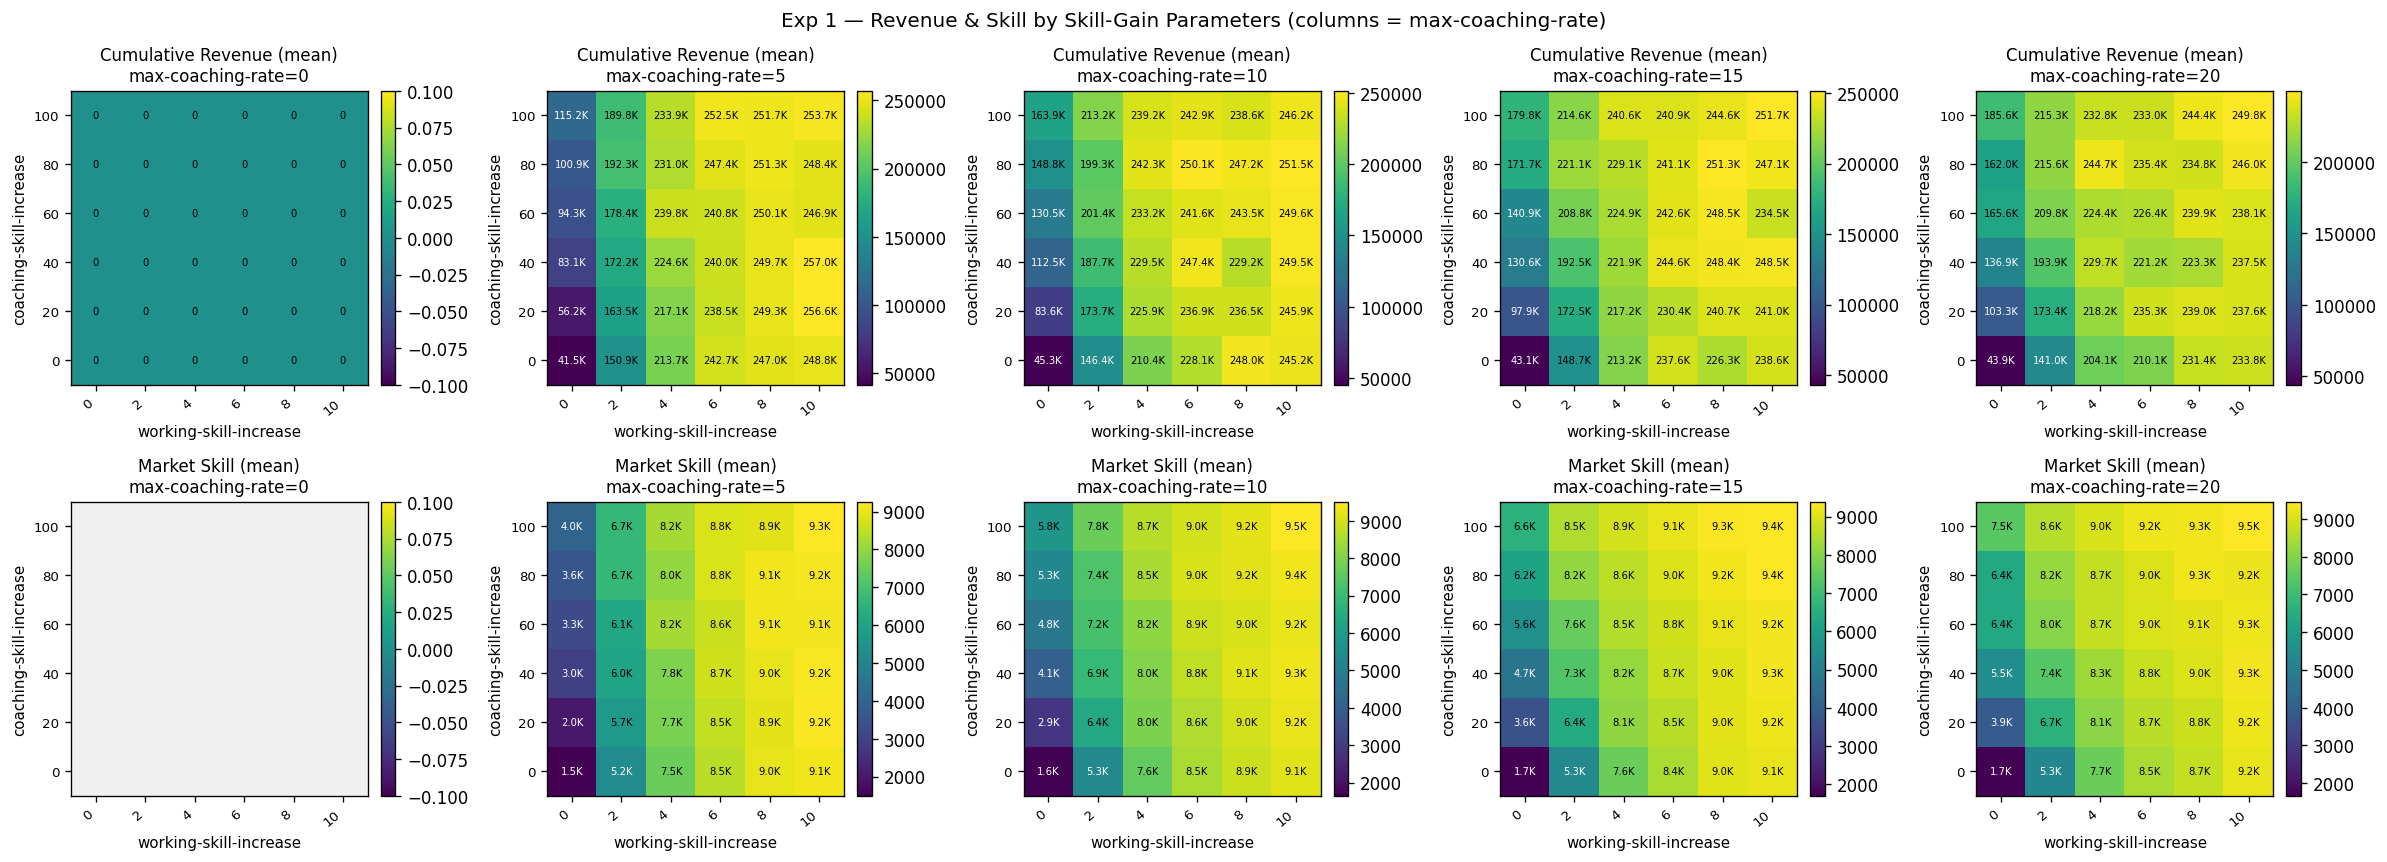

In [36]:
# Faceted heatmaps: coaching-skill-increase × working-skill-increase
# Rows: cumulative revenue | market skill mean
# Columns: one panel per max-coaching-rate level

metrics1  = ['cum_rev_mean', 'skill_mean']
mlabels1  = ['Cumulative Revenue (mean)', 'Market Skill (mean)']

fig1 = make_faceted_heatmaps(
    df1,
    x_param      = 'working-skill-increase',
    y_param      = 'coaching-skill-increase',
    facet_param  = 'max-coaching-rate',
    metrics      = metrics1,
    metric_labels= mlabels1,
)
fig1.suptitle(
    "Exp 1 — Revenue & Skill by Skill-Gain Parameters (columns = max-coaching-rate)",
    y=1.02, fontsize=12
)
plt.show()


Loading time series for selected runs ...


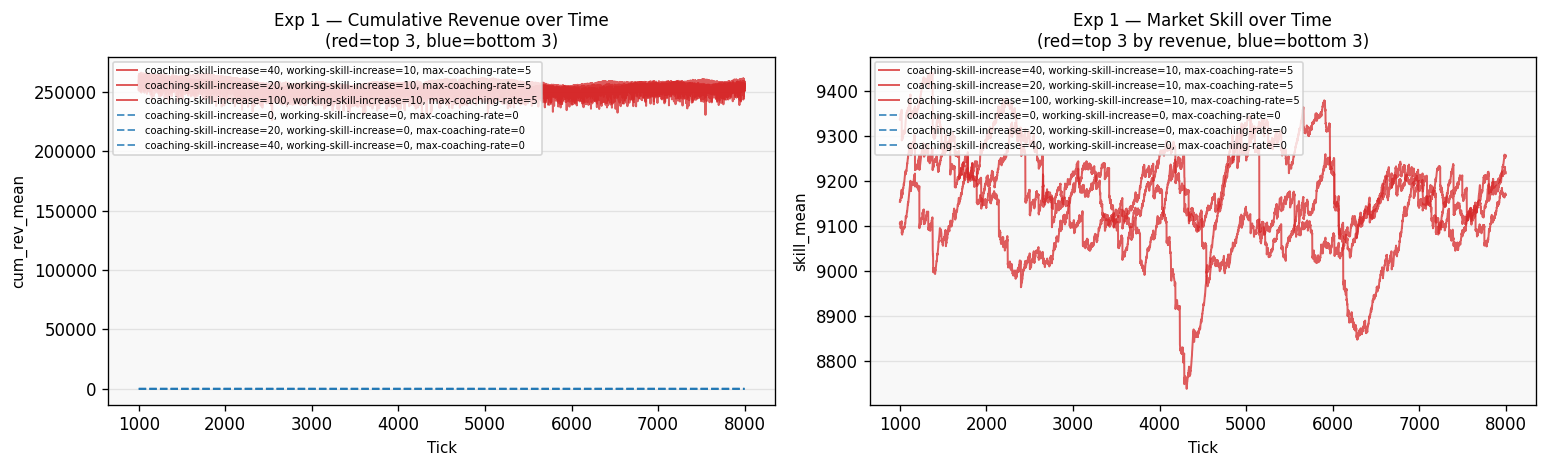

In [37]:
# Time series: top 3 vs bottom 3 runs by final cumulative revenue
top3_ids  = df1.nlargest(3,  'cum_rev_mean')['run'].tolist()
bot3_ids  = df1.nsmallest(3, 'cum_rev_mean')['run'].tolist()
sel_ids   = top3_ids + bot3_ids

print("Loading time series for selected runs ...")
ts1 = load_timeseries(EXP_PATHS[EXP], PARAMS1, run_ids=sel_ids)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('white')

make_ts_lines(axes[0], ts1, sel_ids, df1, PARAMS1,
              'cum_rev_mean', 'Exp 1 — Cumulative Revenue over Time\n(red=top 3, blue=bottom 3)')
make_ts_lines(axes[1], ts1, sel_ids, df1, PARAMS1,
              'skill_mean',   'Exp 1 — Market Skill over Time\n(red=top 3 by revenue, blue=bottom 3)')

plt.tight_layout()
plt.show()


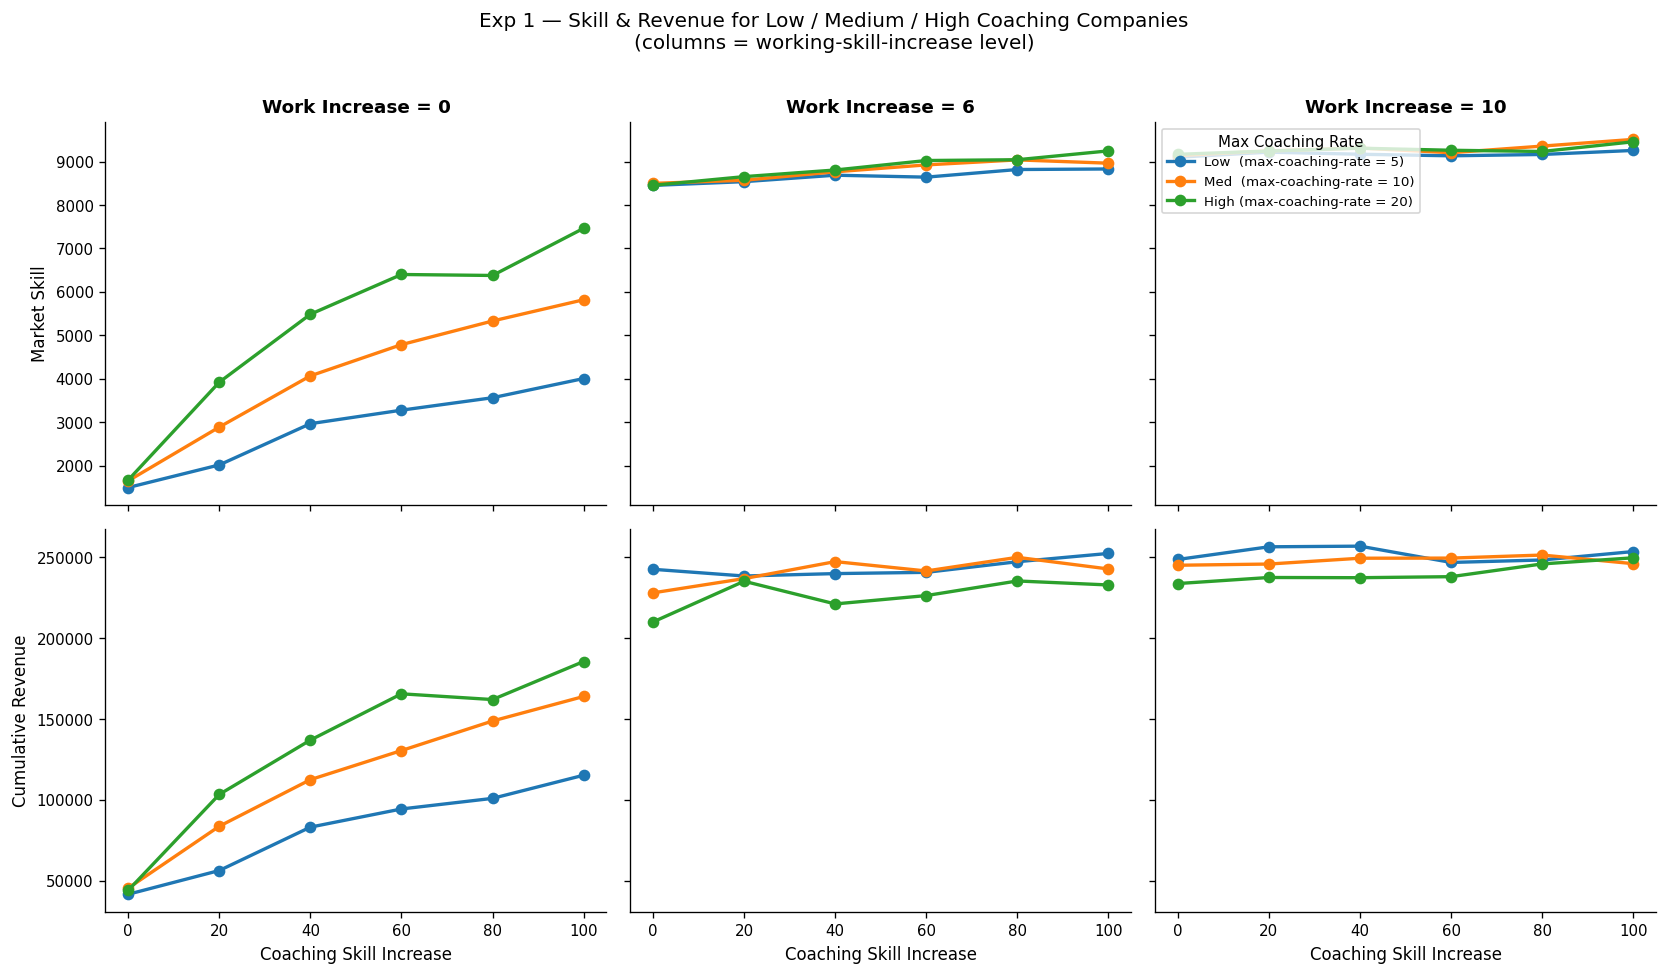

In [38]:
# Individual company view: high / medium / low max-coaching-rate
# ─────────────────────────────────────────────────────────────────────────────
# Instead of plotting means across all companies, pick three representative
# coaching-rate tiers and show how their skill & revenue vary across the
# coaching-skill-increase and working-skill-increase parameter space.

# ── coaching-rate tiers ──────────────────────────────────────────────────
cr_vals  = sorted(df1['max-coaching-rate'].unique())
cr_low   = next(v for v in cr_vals if v > 0)  # lowest non-zero, e.g. 5
cr_mid   = cr_vals[len(cr_vals)//2] # e.g. 10
cr_high  = cr_vals[-1]              # e.g. 20
cr_sel   = [cr_low, cr_mid, cr_high]

cr_labels = {cr_low:  f'Low  (max-coaching-rate = {cr_low})',
             cr_mid:  f'Med  (max-coaching-rate = {cr_mid})',
             cr_high: f'High (max-coaching-rate = {cr_high})'}
cr_colors = {cr_low: '#1f77b4', cr_mid: '#ff7f0e', cr_high: '#2ca02c'}

# ── working-skill-increase levels to facet on ─────────────────────────
wi_vals = sorted(df1['working-skill-increase'].unique())
wi_sel  = [wi_vals[0], wi_vals[len(wi_vals)//2], wi_vals[-1]]  # low, mid, high

metrics  = ['skill_mean',   'cum_rev_mean']
mlabels  = ['Market Skill', 'Cumulative Revenue']

# ── aggregate over replications (if any) ───────────────────────────────
grp = (df1
       .groupby(['max-coaching-rate', 'coaching-skill-increase', 'working-skill-increase'])[metrics]
       .mean()
       .reset_index())

# ── plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(metrics), len(wi_sel),
                         figsize=(14, 8), sharex=True, sharey='row')
fig.patch.set_facecolor('white')

for col, wi in enumerate(wi_sel):
    sub = grp[grp['working-skill-increase'] == wi]

    for row, (metric, mlabel) in enumerate(zip(metrics, mlabels)):
        ax = axes[row, col]
        ax.set_facecolor('white')

        for cr in cr_sel:
            dat = sub[sub['max-coaching-rate'] == cr].sort_values('coaching-skill-increase')
            ax.plot(dat['coaching-skill-increase'], dat[metric],
                    label=cr_labels[cr], color=cr_colors[cr],
                    marker='o', linewidth=2, markersize=6)

        # column title (top row only)
        if row == 0:
            ax.set_title(f'Work Increase = {wi}', fontsize=11, fontweight='bold')

        # y-label (left column only)
        if col == 0:
            ax.set_ylabel(mlabel, fontsize=10)

        # x-label (bottom row only)
        if row == len(metrics) - 1:
            ax.set_xlabel('Coaching Skill Increase', fontsize=10)

        ax.tick_params(labelsize=9)
        ax.spines[['top', 'right']].set_visible(False)

# shared legend in the top-right panel
axes[0, -1].legend(title='Max Coaching Rate', fontsize=8, title_fontsize=9,
                   loc='upper left')

fig.suptitle(
    'Exp 1 — Skill & Revenue for Low / Medium / High Coaching Companies\n'
    '(columns = working-skill-increase level)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

---
## 4 · Coaching Output — Experiment 2: Turnover Dynamics

**Research question:** Under what combination of turnover incentives and leaving thresholds are
turnovers minimised without sacrificing revenue?

### Plots produced
| Plot | What to read |
|---|---|
| Faceted heatmaps (unemployment + revenue) | Each column = one `leaving-threshold`. |
| Interaction plot | Does increasing `coaching-turnover-decrease` help more when `leaving-threshold` is low? |

### Interpretation guide
- **Low unemployment + high revenue** in the same cell → coaching effectively retains talent without sacrificing output.
- **unemployment rises with `working-turnover-increase`** but coaching suppresses it → validates the double-dividend hypothesis (coaching = productivity + retention).
- **`leaving-threshold` facets diverge** → the model is sensitive to how easily developers leave; a low threshold means even small propensity accumulation triggers departure.
- **Interaction plot lines converge** at high `leaving-threshold` → coaching retention benefit is irrelevant when the bar to leave is high.
- **Interaction plot lines diverge** at low `leaving-threshold` → coaching is most valuable when retention is fragile.


In [39]:
EXP2   = "coaching-output-exp2"
PARAMS2 = EXP_PARAMS[EXP2]

print(f"Loading {EXP2} ...")
df2 = load_experiment(EXP_PATHS[EXP2], PARAMS2)
df2.head()


Loading coaching-output-exp2 ...
  Format: spreadsheet
  Runs: 72  |  Metrics: ['dependent-variables', 'revenue-distribution', 'skill-distribution', 'unemployment-rate']
  Loaded 72 runs.  Columns: ['run', 'final_tick', 'working-turnover-increase', 'coaching-turnover-decrease', 'leaving-threshold', 'cum_rev_mean', 'coaching_rate_mean', 'vacancies_mean', 'propensity_mean', 'rev_market_mean', 'rev_market_std', 'rev_market_median', 'skill_mean', 'skill_std', 'skill_median', 'unemployment_rate']


,run,final_tick,working-turnover-increase,coaching-turnover-decrease,leaving-threshold,cum_rev_mean,coaching_rate_mean,vacancies_mean,propensity_mean,rev_market_mean,rev_market_std,rev_market_median,skill_mean,skill_std,skill_median,unemployment_rate
0,1,8000,0.0,0,10,118616.585859,9.330570e+08,123205.080808,2756.797980,118616.585859,45236.759582,130340.0,4230.767603,2018.235739,4252.0,0.029293
1,2,8000,0.1,0,10,132037.727273,1.035928e+09,137491.121212,2257.818182,132037.727273,34048.531329,138054.0,4769.313595,1671.033669,4819.0,0.039057
2,3,8000,0.2,0,10,126513.161616,1.023477e+09,135181.979798,2246.828283,126513.161616,37279.722899,129618.0,4671.209773,1621.730601,4789.0,0.035354
3,4,8000,0.3,0,10,129517.757576,1.021885e+09,134719.575758,2244.959596,129517.757576,31961.343388,138256.0,4673.173791,1586.593772,4729.0,0.039057
4,5,8000,0.4,0,10,124610.161616,1.019766e+09,136957.020202,2042.636364,124610.161616,43984.522466,135447.0,4724.301394,1658.532112,4877.0,0.033670


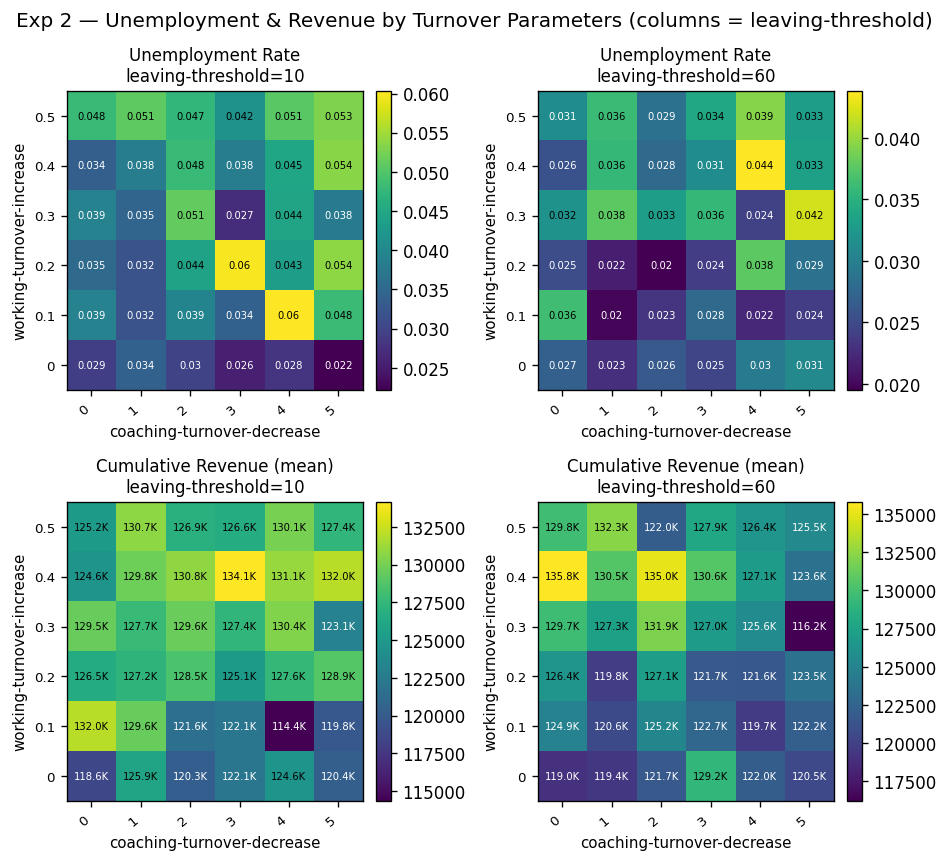

In [40]:
metrics2 = ['unemployment_rate', 'cum_rev_mean']
mlabels2 = ['Unemployment Rate', 'Cumulative Revenue (mean)']

fig2 = make_faceted_heatmaps(
    df2,
    x_param      = 'coaching-turnover-decrease',
    y_param      = 'working-turnover-increase',
    facet_param  = 'leaving-threshold',
    metrics      = metrics2,
    metric_labels= mlabels2,
)
fig2.suptitle(
    "Exp 2 — Unemployment & Revenue by Turnover Parameters (columns = leaving-threshold)",
    y=1.02, fontsize=12
)
plt.show()


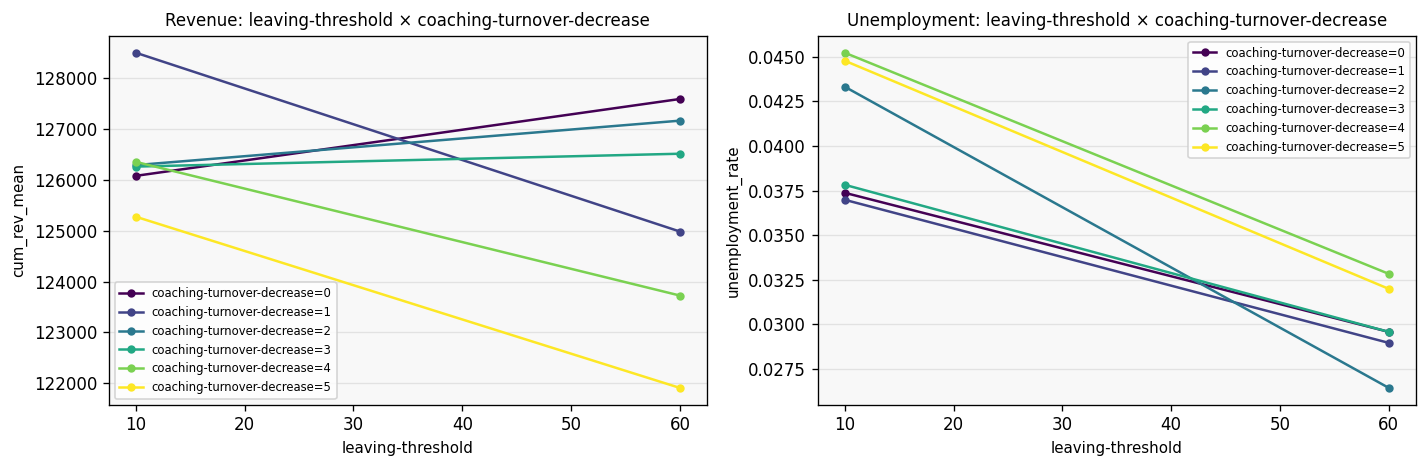

In [41]:
# Interaction: leaving-threshold × coaching-turnover-decrease → revenue
# Shows whether coaching retention benefit is more valuable when threshold is low

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

make_interaction_plot(
    axes[0], df2,
    x_param='leaving-threshold', group_param='coaching-turnover-decrease',
    metric='cum_rev_mean',
    title='Revenue: leaving-threshold × coaching-turnover-decrease'
)
make_interaction_plot(
    axes[1], df2,
    x_param='leaving-threshold', group_param='coaching-turnover-decrease',
    metric='unemployment_rate',
    title='Unemployment: leaving-threshold × coaching-turnover-decrease'
)

plt.tight_layout()
plt.show()


---
## 5 · Coaching Output — Experiment 3: Skill Decay

**Research question:** How damaging is skill obsolescence? Can companies outrun decay with coaching?

**Note:** Only 25 runs (5 × 5 grid) — this experiment produces one clean heatmap per outcome.

### Plots produced
| Plot | What to read |
|---|---|
| Heatmap: skill × revenue | Does the decay rate matter more or the threshold before decay starts? |
| Time series: extreme combos | When does the divergence appear? |

### Interpretation guide
- **Top-right corner (high threshold, low rate) ≈ bottom-left (low threshold, high rate)**
  → decay impact is symmetric: you can tolerate a high rate if the threshold is generous.
- **Diagonal split** in the heatmap → one parameter dominates; the other barely matters.
- **Revenue and skill heatmaps misaligned** → companies can compensate for skill loss via hiring but cannot fully recover revenue.
- **Time series diverges early** (< tick 2000) → decay is rapid and immediate; companies have no grace period.
- **Divergence only after tick 6000** → skill decay is a slow-burn risk; harmless in the short term.


In [42]:
EXP3    = "coaching-output-exp3"
PARAMS3 = EXP_PARAMS[EXP3]

print(f"Loading {EXP3} ...")
df3 = load_experiment(EXP_PATHS[EXP3], PARAMS3)
df3


Loading coaching-output-exp3 ...
  Format: spreadsheet
  Runs: 25  |  Metrics: ['dependent-variables', 'revenue-distribution', 'skill-distribution', 'unemployment-rate']
  Loaded 25 runs.  Columns: ['run', 'final_tick', 'skill-decay-threshold', 'skill-decay-rate', 'cum_rev_mean', 'coaching_rate_mean', 'vacancies_mean', 'propensity_mean', 'rev_market_mean', 'rev_market_std', 'rev_market_median', 'skill_mean', 'skill_std', 'skill_median', 'unemployment_rate']


,run,final_tick,skill-decay-threshold,skill-decay-rate,cum_rev_mean,coaching_rate_mean,vacancies_mean,propensity_mean,rev_market_mean,rev_market_std,rev_market_median,skill_mean,skill_std,skill_median,unemployment_rate
0,1,8000,100,0.00,134962.252525,1.023475e+09,136418.858586,2123.595960,134962.252525,20407.274743,136350.0,4674.789547,1640.533932,4775.0,0.027273
1,2,8000,200,0.00,131306.494949,1.031775e+09,137297.686869,2148.767677,131306.494949,31918.590343,138691.0,4724.529371,1673.355527,4893.0,0.031313
2,3,8000,300,0.00,126607.626263,1.017616e+09,133412.848485,2226.070707,126607.626263,33899.700218,130792.0,4595.640919,1593.756880,4621.0,0.032323
3,4,8000,400,0.00,127935.717172,1.022976e+09,134839.262626,2191.474747,127935.717172,33765.330973,135922.0,4638.320709,1612.062897,4681.5,0.030976
4,5,8000,500,0.00,135276.474747,1.046860e+09,141085.525253,2302.111111,135276.474747,34003.280598,143059.0,4866.713240,1704.708337,5004.5,0.033670
5,6,8000,100,0.05,125671.737374,9.819424e+08,128385.222222,2321.767677,125671.737374,24610.050315,129577.0,4413.242014,1493.588252,4500.0,0.030303
6,7,8000,200,0.05,130060.959596,1.016908e+09,133796.393939,2237.515152,130060.959596,27753.099332,133736.0,4639.524694,1605.287941,4721.0,0.038721
7,8,8000,300,0.05,125527.080808,1.015559e+09,133597.191919,2207.333333,125527.080808,35608.715479,131475.0,4595.594858,1645.061643,4627.5,0.030976
8,9,8000,400,0.05,130628.383838,1.020325e+09,135733.555556,2268.878788,130628.383838,32344.146469,136416.0,4652.916205,1645.649073,4730.5,0.027609
9,10,8000,500,0.05,125891.050505,1.021247e+09,133958.333333,2215.343434,125891.050505,35715.659028,132781.0,4611.222184,1624.387116,4687.0,0.031650


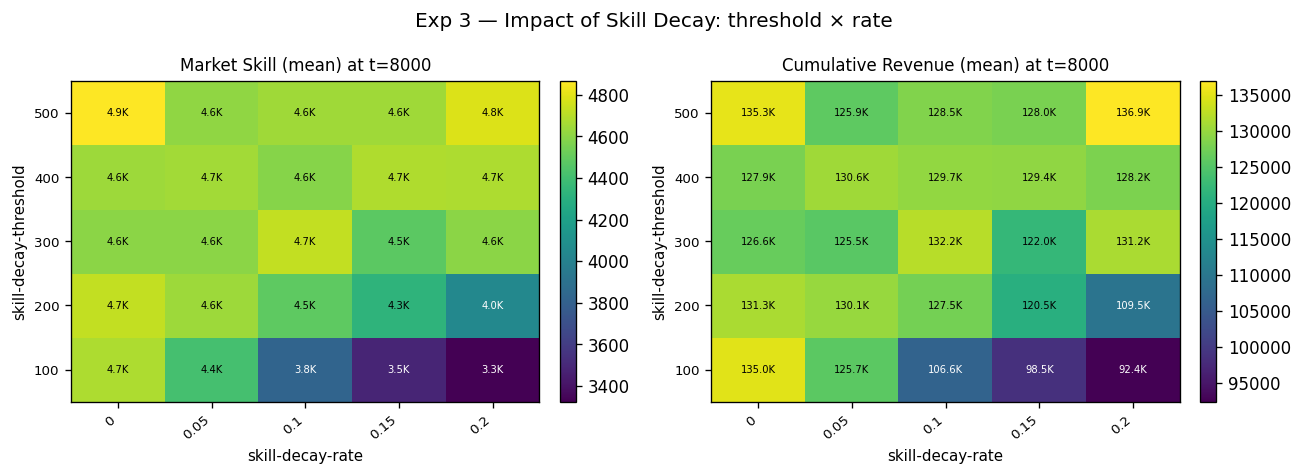

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor('white')

if 'skill_mean' in df3.columns:
    make_heatmap(axes[0], df3, 'skill-decay-rate', 'skill-decay-threshold',
                 'skill_mean', 'Market Skill (mean) at t=8000')
if 'cum_rev_mean' in df3.columns:
    make_heatmap(axes[1], df3, 'skill-decay-rate', 'skill-decay-threshold',
                 'cum_rev_mean', 'Cumulative Revenue (mean) at t=8000')

fig.suptitle("Exp 3 — Impact of Skill Decay: threshold × rate", fontsize=12)
plt.tight_layout()
plt.show()


Loading time series...


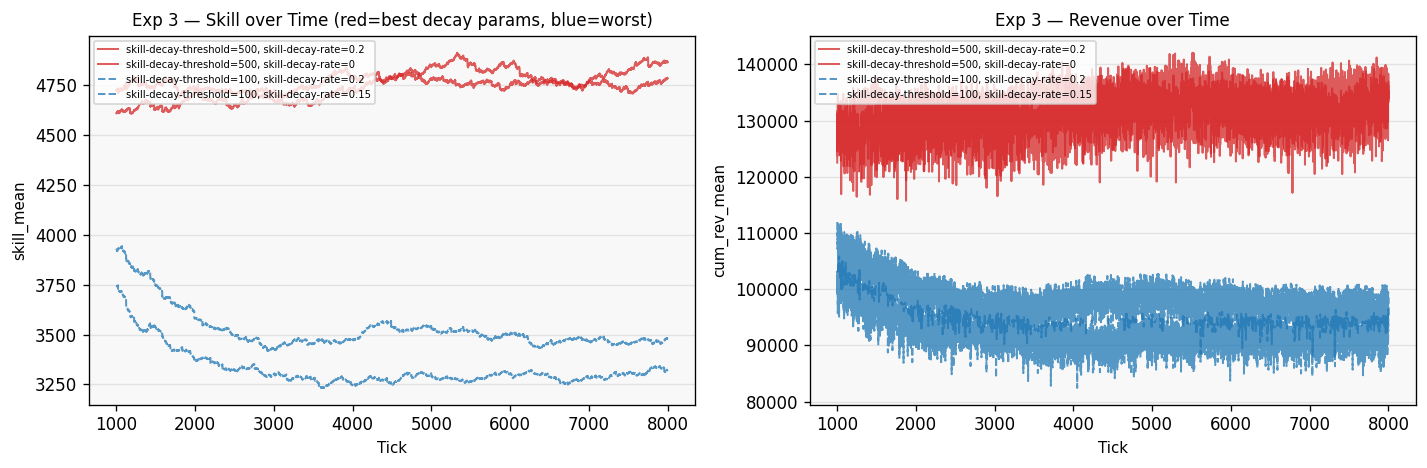

In [44]:
# Time series: worst decay (low threshold, high rate) vs best (high threshold, low rate)
top2  = df3.nlargest(2,  'cum_rev_mean')['run'].tolist() if 'cum_rev_mean' in df3.columns else []
bot2  = df3.nsmallest(2, 'cum_rev_mean')['run'].tolist() if 'cum_rev_mean' in df3.columns else []
sel3  = top2 + bot2

if sel3:
    print("Loading time series...")
    ts3 = load_timeseries(EXP_PATHS[EXP3], PARAMS3, run_ids=sel3)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor('white')
    make_ts_lines(axes[0], ts3, sel3, df3, PARAMS3, 'skill_mean',
                  'Exp 3 — Skill over Time (red=best decay params, blue=worst)')
    make_ts_lines(axes[1], ts3, sel3, df3, PARAMS3, 'cum_rev_mean',
                  'Exp 3 — Revenue over Time')
    plt.tight_layout()
    plt.show()


---
## 6 · Strategy — Experiment 1: Review Cadence × Turnover Pressure

**Research question:** How often should companies revise their strategy, and does it matter more
when turnover pressure is high?

### Plots produced
| Plot | What to read |
|---|---|
| Line: review-interval → revenue (one line per `working-turnover-increase`) | Is the benefit of frequent review larger under higher turnover pressure? |
| Heatmap: review-interval × leaving-threshold | Does the threshold interact with review cadence? |

### Interpretation guide
- **Revenue flat across review intervals** → strategy adaptation adds nothing; the model reaches the same equilibrium regardless of how often firms reassess.
- **Revenue peaks at intermediate interval (e.g. 200–300)** → too-frequent review is destabilizing (firms never converge to a policy); too-infrequent misses pressure signals.
- **Lines spread apart as `working-turnover-increase` grows** → strategy review is most valuable when working drives up turnover; without pressure, it is irrelevant.
- **Heatmap: top-right = high interval + high threshold** → high threshold insulates firms from turnover, making frequent review unnecessary.
- **Heatmap: top-left = low interval + high threshold** → frequent review actively hurts when developers are stable (overreacting to noise).


In [45]:
EXP4    = "strategy-exp1"
PARAMS4 = EXP_PARAMS[EXP4]

print(f"Loading {EXP4} ...")
df4 = load_experiment(EXP_PATHS[EXP4], PARAMS4)
df4.head()


Loading strategy-exp1 ...
  Format: table
  Params from data columns : ['coaching-turnover-decrease', 'leaving-threshold', 'strategy-review-interval', 'working-turnover-increase']
  Params from header rows  : []
  Loaded 150 runs.  Columns: ['run', 'final_tick', 'strategy-review-interval', 'working-turnover-increase', 'coaching-turnover-decrease', 'leaving-threshold', 'cum_rev_mean', 'coaching_rate_mean', 'vacancies_mean', 'propensity_mean', 'rev_market_mean', 'rev_market_std', 'rev_market_median', 'skill_mean', 'skill_std', 'skill_median', 'unemployment_rate']


,run,final_tick,strategy-review-interval,working-turnover-increase,coaching-turnover-decrease,leaving-threshold,cum_rev_mean,coaching_rate_mean,vacancies_mean,propensity_mean,rev_market_mean,rev_market_std,rev_market_median,skill_mean,skill_std,skill_median,unemployment_rate
0,1,8000,50,0.1,1,10,126134.333333,1.015562e+09,133334.939394,2331.757576,126134.333333,35226.828138,132583.0,4634.887289,1646.759227,4727.5,0.041077
1,2,8000,150,0.1,1,10,130155.787879,1.008870e+09,134203.909091,1933.898990,130155.787879,30182.734759,132976.0,4650.397970,1665.583504,4729.0,0.038047
2,3,8000,250,0.1,1,10,128227.444444,1.013684e+09,133718.161616,2043.545455,128227.444444,33654.861056,130390.0,4644.946667,1611.423247,4693.5,0.040404
3,4,8000,350,0.1,1,10,124013.434343,1.019499e+09,132570.646465,1834.878788,124013.434343,38022.008996,133969.0,4621.300704,1690.431151,4629.0,0.043771
4,5,8000,450,0.1,1,10,128007.767677,9.979638e+08,132031.424242,1865.545455,128007.767677,29733.498170,129603.0,4573.516795,1646.006714,4641.0,0.037710


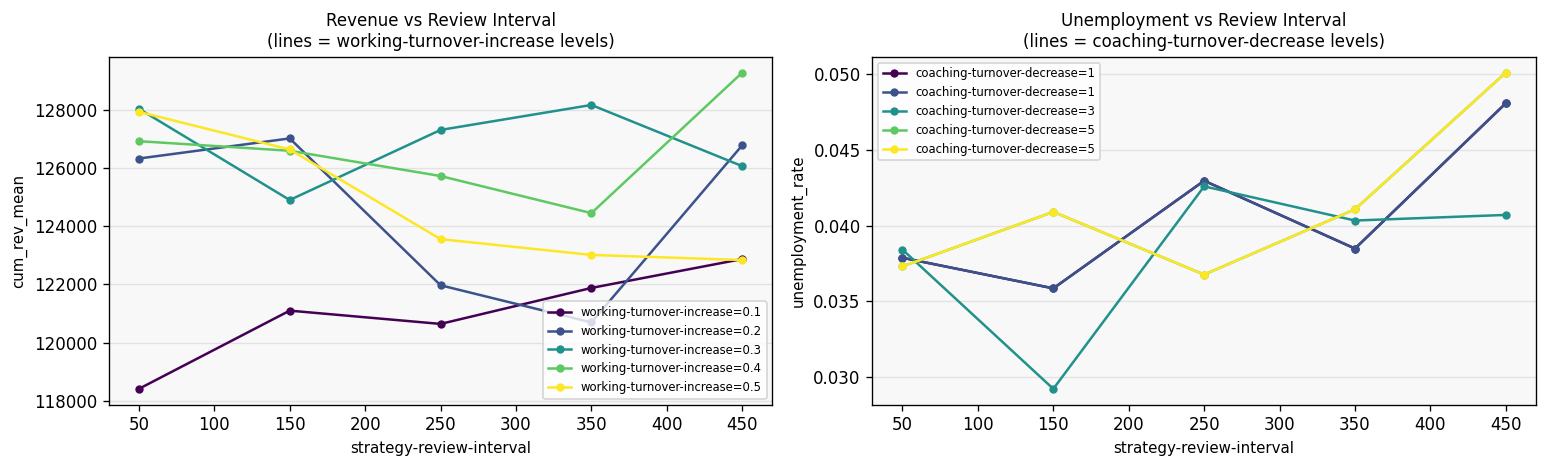

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('white')

# Left: review-interval × working-turnover-increase → revenue
make_interaction_plot(
    axes[0], df4,
    x_param='strategy-review-interval', group_param='working-turnover-increase',
    metric='cum_rev_mean', n_groups=5,
    title='Revenue vs Review Interval\n(lines = working-turnover-increase levels)'
)

# Right: review-interval × coaching-turnover-decrease → unemployment
make_interaction_plot(
    axes[1], df4,
    x_param='strategy-review-interval', group_param='coaching-turnover-decrease',
    metric='unemployment_rate', n_groups=5,
    title='Unemployment vs Review Interval\n(lines = coaching-turnover-decrease levels)'
)

plt.tight_layout()
plt.show()


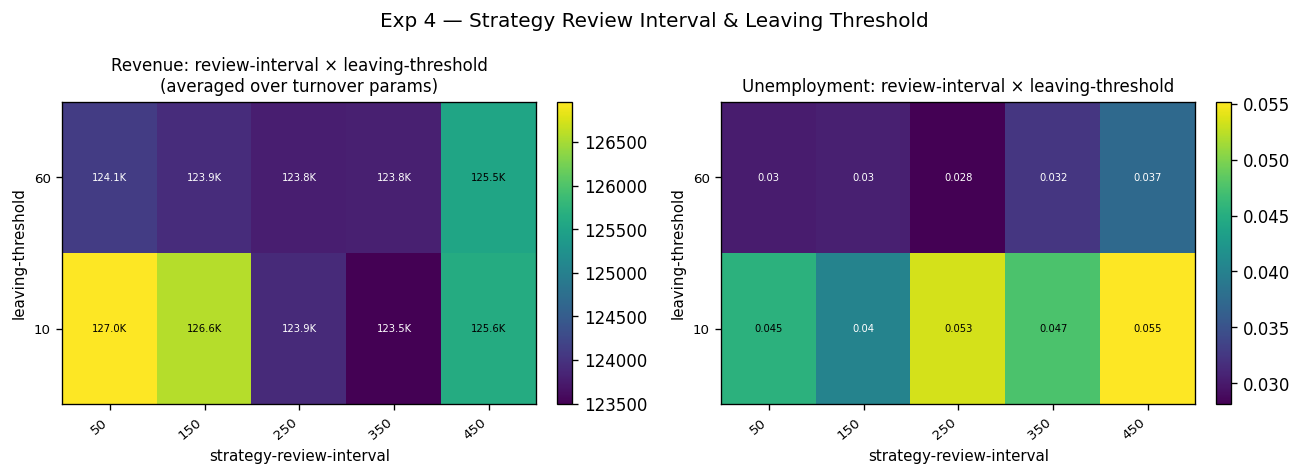

In [47]:
# Heatmap averaged over coaching/working turnover params:
# review-interval × leaving-threshold → revenue
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor('white')

if 'cum_rev_mean' in df4.columns:
    make_heatmap(axes[0], df4, 'strategy-review-interval', 'leaving-threshold',
                 'cum_rev_mean', 'Revenue: review-interval × leaving-threshold\n(averaged over turnover params)')
if 'unemployment_rate' in df4.columns:
    make_heatmap(axes[1], df4, 'strategy-review-interval', 'leaving-threshold',
                 'unemployment_rate', 'Unemployment: review-interval × leaving-threshold')

fig.suptitle("Exp 4 — Strategy Review Interval & Leaving Threshold", fontsize=12)
plt.tight_layout()
plt.show()


---
## 7 · Strategy — Experiment 2: Market Variance & Vacancy Tolerance

**Research question:** How do heterogeneity in firm size/hiring standards and vacancy tolerance
affect market-level revenue stability and unemployment?

### Plots produced
| Plot | What to read |
|---|---|
| Efficiency frontier scatter | Which runs achieve both high revenue AND low variance? |
| Heatmap: variance dims → unemployment | Which variance source drives market exclusion? |
| Interaction: vacancy-cutoff × review-interval | Does a tight cutoff make frequent review more important? |

### Interpretation guide
- **Efficiency frontier**: runs in the top-left of the revenue vs. std scatter achieve high mean AND low inequality. Color encodes `vacancy-rate-cutoff`. If tight cutoffs cluster top-left, that is the policy recommendation.
- **`hiring-threshold-variance` dominates unemployment** → when firms differ a lot in standards, many developers cannot find a match; market fragmentation hurts workers.
- **`headcount-variance` dominates unemployment** → it is firm size inequality that drives exclusion, not standard inequality.
- **Vacancy-cutoff effect on interaction**: if the lines diverge at low review intervals, then loose cutoffs (firms tolerate vacancies) make the system resilient to infrequent review; tight cutoffs (aggressive lowering of standards under pressure) benefit from frequent reassessment.


In [48]:
EXP5    = "strategy-exp2"
PARAMS5 = EXP_PARAMS[EXP5]

print(f"Loading {EXP5} ...")
df5 = load_experiment(EXP_PATHS[EXP5], PARAMS5)
df5.head()


Loading strategy-exp2 ...
  Format: table
  Params from data columns : ['headcount-variance', 'hiring-threshold-variance', 'strategy-review-interval', 'vacancy-rate-cutoff']
  Params from header rows  : []
  Loaded 270 runs.  Columns: ['run', 'final_tick', 'strategy-review-interval', 'headcount-variance', 'hiring-threshold-variance', 'vacancy-rate-cutoff', 'cum_rev_mean', 'coaching_rate_mean', 'vacancies_mean', 'propensity_mean', 'rev_market_mean', 'rev_market_std', 'rev_market_median', 'skill_mean', 'skill_std', 'skill_median', 'unemployment_rate']


,run,final_tick,strategy-review-interval,headcount-variance,hiring-threshold-variance,vacancy-rate-cutoff,cum_rev_mean,coaching_rate_mean,vacancies_mean,propensity_mean,rev_market_mean,rev_market_std,rev_market_median,skill_mean,skill_std,skill_median,unemployment_rate
0,1,8000,50,0,0,0.0,132524.343434,1.038091e+09,139146.525253,2021.000000,132524.343434,33306.817601,138954.0,4699.933811,1624.249053,4733.0,0.013131
1,2,8000,150,0,0,0.0,131106.202020,1.025095e+09,137049.080808,1690.565657,131106.202020,30012.497397,137392.0,4583.736149,1619.923440,4689.5,0.003367
2,3,8000,250,0,0,0.0,129471.404040,1.043234e+09,136151.858586,1841.555556,129471.404040,33066.242369,136514.0,4583.146549,1626.382407,4638.0,0.009764
3,4,8000,350,0,0,0.0,132040.131313,1.047495e+09,138215.030303,1599.686869,132040.131313,29466.868369,137956.0,4633.690484,1679.414418,4714.0,0.005724
4,5,8000,450,0,0,0.0,130678.353535,1.041964e+09,139334.656566,1702.616162,130678.353535,36511.808156,138971.0,4709.501878,1659.593996,4720.0,0.013805


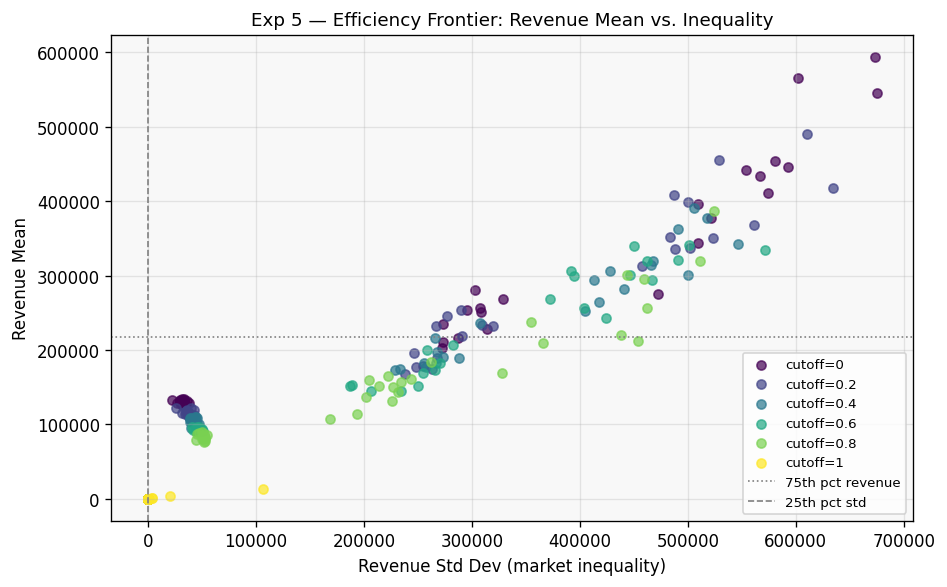

In [49]:
# Efficiency frontier: mean revenue vs revenue std (market inequality)
# Colored by vacancy-rate-cutoff

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f8f8')

y_col = 'rev_market_mean' if 'rev_market_mean' in df5.columns else 'cum_rev_mean'
x_col = 'rev_market_std'  if 'rev_market_std'  in df5.columns else None

if x_col and y_col in df5.columns:
    cutoffs = sorted(df5['vacancy-rate-cutoff'].unique())
    cmap_fn = plt.get_cmap(CMAP)
    colors  = {v: cmap_fn(i / max(len(cutoffs)-1, 1)) for i, v in enumerate(cutoffs)}

    for cutoff, color in colors.items():
        sub = df5[df5['vacancy-rate-cutoff'] == cutoff]
        ax.scatter(sub[x_col], sub[y_col], color=color, alpha=0.7, s=30,
                   label=f"cutoff={cutoff:.2g}")

    # Annotate Pareto front
    ax.axhline(df5[y_col].quantile(0.75), color='grey', linestyle=':', linewidth=1,
               label='75th pct revenue')
    ax.axvline(df5[x_col].quantile(0.25), color='grey', linestyle='--', linewidth=1,
               label='25th pct std')

    ax.set_xlabel("Revenue Std Dev (market inequality)", fontsize=10)
    ax.set_ylabel("Revenue Mean", fontsize=10)
    ax.set_title("Exp 5 — Efficiency Frontier: Revenue Mean vs. Inequality", fontsize=11)
    ax.legend(fontsize=8, loc='best', framealpha=0.8)
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "revenue-distribution not found in CSV",
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()


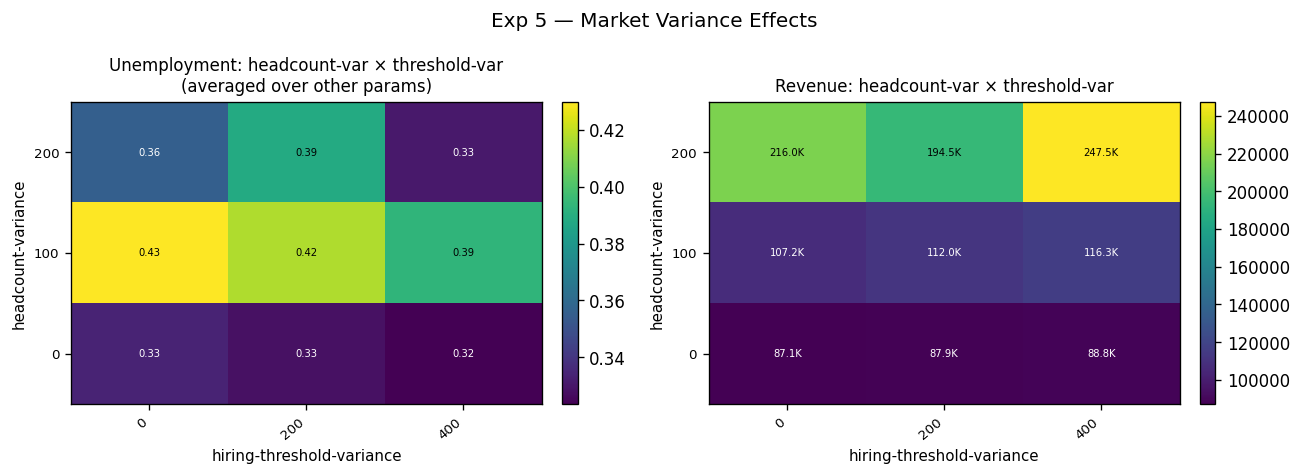

In [50]:
# Heatmaps: headcount-variance × hiring-threshold-variance
# Rows: unemployment | revenue  (averaged over strategy-review-interval and vacancy-rate-cutoff)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor('white')

if 'unemployment_rate' in df5.columns:
    make_heatmap(axes[0], df5, 'hiring-threshold-variance', 'headcount-variance',
                 'unemployment_rate',
                 'Unemployment: headcount-var × threshold-var\n(averaged over other params)')
if 'cum_rev_mean' in df5.columns:
    make_heatmap(axes[1], df5, 'hiring-threshold-variance', 'headcount-variance',
                 'cum_rev_mean',
                 'Revenue: headcount-var × threshold-var')

fig.suptitle("Exp 5 — Market Variance Effects", fontsize=12)
plt.tight_layout()
plt.show()


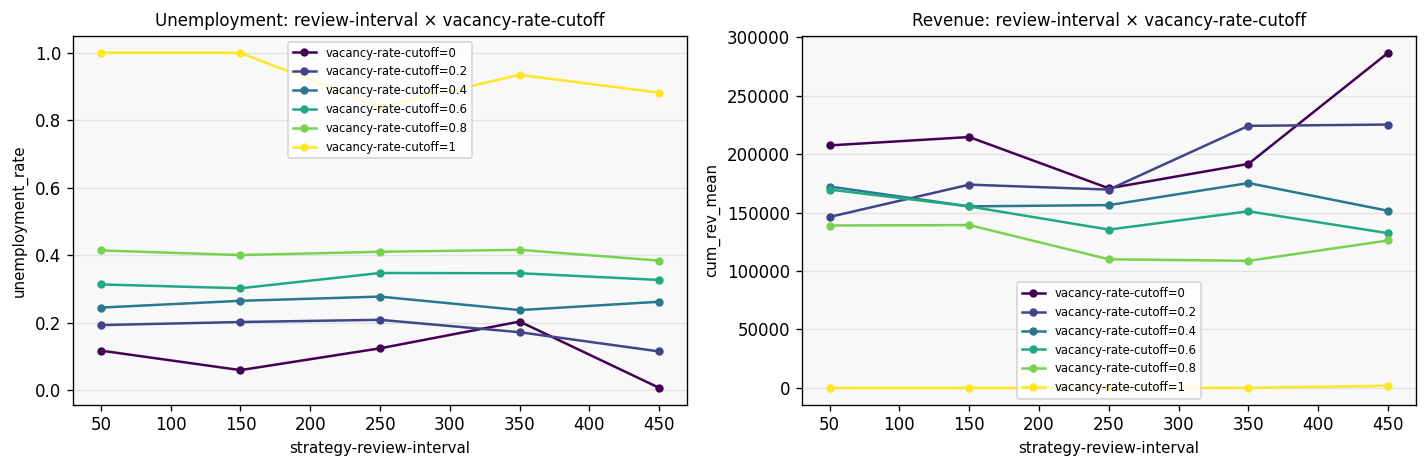

In [51]:
# Interaction: strategy-review-interval × vacancy-rate-cutoff → unemployment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

make_interaction_plot(
    axes[0], df5,
    x_param='strategy-review-interval', group_param='vacancy-rate-cutoff',
    metric='unemployment_rate',
    title='Unemployment: review-interval × vacancy-rate-cutoff'
)
make_interaction_plot(
    axes[1], df5,
    x_param='strategy-review-interval', group_param='vacancy-rate-cutoff',
    metric='cum_rev_mean',
    title='Revenue: review-interval × vacancy-rate-cutoff'
)

plt.tight_layout()
plt.show()


---
## 8 · Strategy — Experiment 3: Coaching Limits

**Research question:** Does capping skill accumulation (via ceiling or diminishing returns) constrain
market performance, and can frequent strategy review compensate?

### Plots produced
| Plot | What to read |
|---|---|
| Lines: coaching-skill-ceiling → skill/revenue, split by `diminishing-returns-coaching` | Does the ceiling matter differently with/without diminishing returns? |
| Heatmap: review-interval × coaching-skill-ceiling | Can faster review make up for tighter ceilings? |

### Interpretation guide
- **Flat skill/revenue line across ceiling values** → the ceiling is never reached; increasing it adds nothing. The model operates below the ceiling even with unlimited coaching.
- **Steep slope and gap between on/off lines** → diminishing returns are a binding constraint at this ceiling; actual ceiling only matters if diminishing returns are off.
- **`diminishing-returns-coaching=False` reaches plateau at high ceiling** → even without diminishing returns, there is a natural skill saturation; the ceiling is binding only within a narrow window.
- **Heatmap: bottom-right hot (low interval, high ceiling)** → frequent review compensates for restricted coaching by dynamically adjusting strategies.
- **Heatmap: uniform across review-interval** → strategy review is irrelevant once coaching is constrained; ceiling is the dominant factor.


In [52]:
EXP6    = "strategy-exp3"
PARAMS6 = EXP_PARAMS[EXP6]

print(f"Loading {EXP6} ...")
df6 = load_experiment(EXP_PATHS[EXP6], PARAMS6)
df6.head()


Loading strategy-exp3 ...
  Format: table
  Params from data columns : ['coaching-skill-ceiling', 'diminishing-returns-coaching', 'strategy-review-interval']
  Params from header rows  : []
  Loaded 100 runs.  Columns: ['run', 'final_tick', 'strategy-review-interval', 'coaching-skill-ceiling', 'diminishing-returns-coaching', 'cum_rev_mean', 'coaching_rate_mean', 'vacancies_mean', 'propensity_mean', 'rev_market_mean', 'rev_market_std', 'rev_market_median', 'skill_mean', 'skill_std', 'skill_median', 'unemployment_rate']


,run,final_tick,strategy-review-interval,coaching-skill-ceiling,diminishing-returns-coaching,cum_rev_mean,coaching_rate_mean,vacancies_mean,propensity_mean,rev_market_mean,rev_market_std,rev_market_median,skill_mean,skill_std,skill_median,unemployment_rate
0,1,8000,50,2000,True,53518.777778,4.218536e+08,55332.707071,1903.979798,53518.777778,13471.308269,59228.0,1976.881270,88.370115,2000.0,0.067003
1,2,8000,100,2000,True,49623.818182,4.150791e+08,53746.969697,1750.252525,49623.818182,18839.986420,58000.0,1968.534961,101.200284,2000.0,0.089899
2,3,8000,150,2000,True,49337.303030,4.040267e+08,52326.333333,1750.575758,49337.303030,20254.954982,59606.0,1986.314034,57.932721,2000.0,0.121886
3,4,8000,200,2000,True,45930.333333,3.922803e+08,49504.030303,1774.686869,45930.333333,23566.252694,59523.0,1981.762636,70.533576,2000.0,0.167340
4,5,8000,250,2000,True,48991.303030,3.870733e+08,50202.838384,1751.444444,48991.303030,21986.338215,59529.0,1980.901156,68.786205,2000.0,0.155219


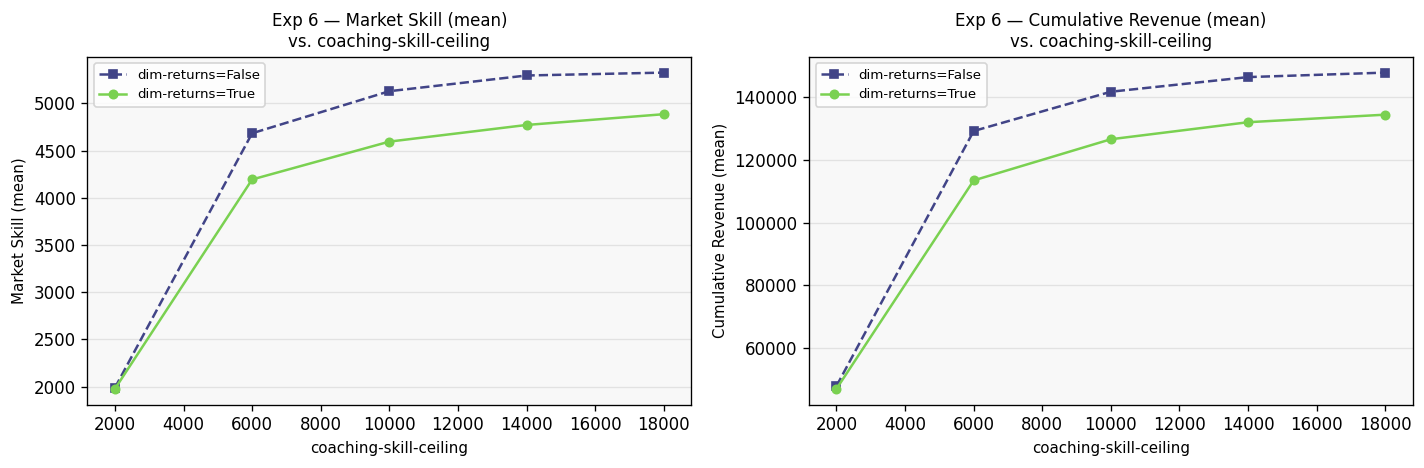

In [53]:
# Lines: coaching-skill-ceiling → outcome
# Two lines per plot: diminishing-returns-coaching = True vs False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

cmap_fn = plt.get_cmap(CMAP)
dim_vals = sorted(df6['diminishing-returns-coaching'].unique())
colors   = {True: cmap_fn(0.8), False: cmap_fn(0.2)}
styles   = {True: '-o', False: '--s'}

for metric, ax, ylabel in [
    ('skill_mean',    axes[0], 'Market Skill (mean)'),
    ('cum_rev_mean',  axes[1], 'Cumulative Revenue (mean)'),
]:
    if metric not in df6.columns:
        ax.set_title(f"{metric} — no data")
        continue
    for dim in dim_vals:
        sub = df6[df6['diminishing-returns-coaching'] == dim].groupby('coaching-skill-ceiling')[metric].mean()
        ax.plot(sub.index, sub.values, styles.get(dim, '-o'),
                color=colors.get(dim, 'grey'), markersize=5,
                label=f"dim-returns={dim}")
    ax.set_xlabel('coaching-skill-ceiling', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(f'Exp 6 — {ylabel}\nvs. coaching-skill-ceiling', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_facecolor('#f8f8f8')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


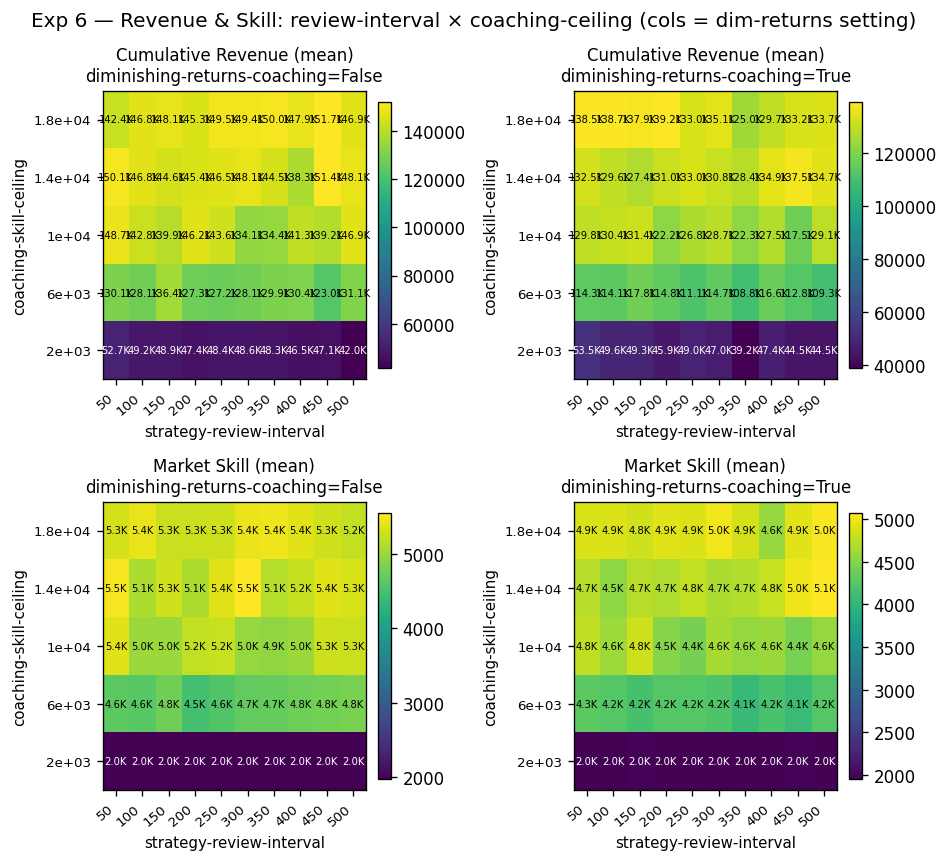

In [54]:
# Heatmap: strategy-review-interval × coaching-skill-ceiling → revenue
# Faceted by diminishing-returns-coaching (True / False)

fig6h = make_faceted_heatmaps(
    df6,
    x_param      = 'strategy-review-interval',
    y_param      = 'coaching-skill-ceiling',
    facet_param  = 'diminishing-returns-coaching',
    metrics      = ['cum_rev_mean', 'skill_mean'],
    metric_labels= ['Cumulative Revenue (mean)', 'Market Skill (mean)'],
)
fig6h.suptitle(
    "Exp 6 — Revenue & Skill: review-interval × coaching-ceiling (cols = dim-returns setting)",
    y=1.02, fontsize=12
)
plt.show()


---
## 9 · Cross-Experiment Synthesis

Combines the final-tick outcomes from all six experiments to answer:
> **Where in the full parameter space do revenue and skill align? Where do they conflict?**

### Plots produced
| Plot | What to read |
|---|---|
| Revenue vs. skill scatter (all runs) | Upper-right = both high. Upper-left = revenue without skill. Lower-right = skill without revenue. |
| Revenue vs. unemployment scatter | Upper-left = high revenue + low unemployment = best outcome. |

### Interpretation guide
- **Tight cluster** → most parameter combinations lead to similar outcomes; the model is robust and outcomes are not parameter-sensitive.
- **Elongated along revenue axis** → skill level does not translate to revenue; coaching accumulates skill but does not convert it to output.
- **Cluster separates by experiment** (color) → the answer to the research question differs qualitatively across the coaching vs. strategy dimension.
- **Pareto outliers** in the top-left of the unemployment plot → identify which experiment and which parameter combo achieves the best joint outcome for the presentation slide.


In [55]:
# Combine all experiments into one DataFrame
dfs_all = []
exp_labels = {
    'df1': 'C-Exp1: skill-gains',
    'df2': 'C-Exp2: turnover',
    'df3': 'C-Exp3: decay',
    'df4': 'S-Exp1: review×turnover',
    'df5': 'S-Exp2: variance',
    'df6': 'S-Exp3: ceiling',
}
for name, df_exp in [('df1', df1), ('df2', df2), ('df3', df3),
                      ('df4', df4), ('df5', df5), ('df6', df6)]:
    try:
        tmp = df_exp[['run', 'cum_rev_mean']].copy()
        for col in ['skill_mean', 'unemployment_rate', 'propensity_mean', 'rev_market_std']:
            if col in df_exp.columns:
                tmp[col] = df_exp[col]
        tmp['experiment'] = exp_labels[name]
        dfs_all.append(tmp)
    except Exception as e:
        print(f"Skipping {name}: {e}")

if dfs_all:
    df_all = pd.concat(dfs_all, ignore_index=True)
    print(f"Combined: {len(df_all)} runs across {df_all['experiment'].nunique()} experiments")
    df_all.describe()


Combined: 797 runs across 6 experiments


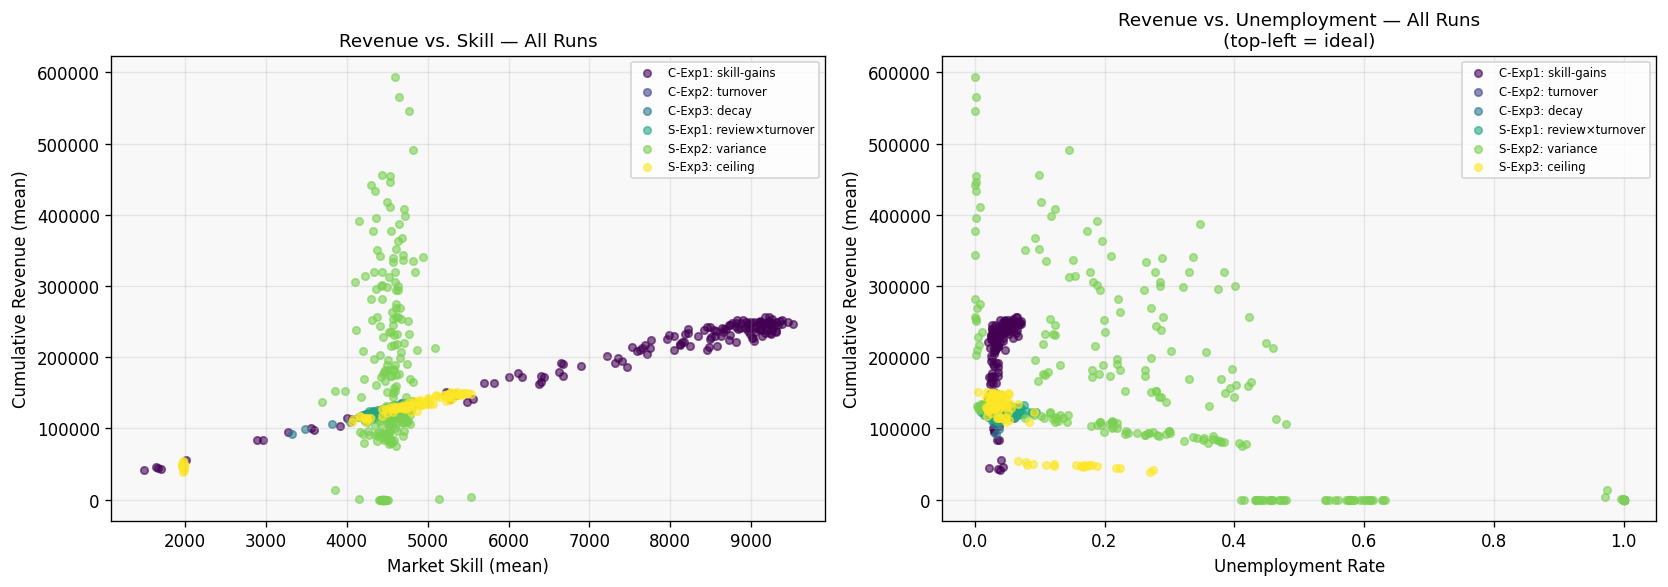

In [56]:
if 'df_all' not in dir() or df_all.empty:
    print("No combined data — run the cell above first.")
else:
    experiments = df_all['experiment'].unique()
    cmap_fn = plt.get_cmap(CMAP)
    colors  = {exp: cmap_fn(i / max(len(experiments)-1, 1))
               for i, exp in enumerate(experiments)}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('white')

    # Left: revenue vs skill
    ax = axes[0]
    ax.set_facecolor('#f8f8f8')
    if 'skill_mean' in df_all.columns:
        for exp, color in colors.items():
            sub = df_all[df_all['experiment'] == exp]
            ax.scatter(sub['skill_mean'], sub['cum_rev_mean'],
                       color=color, alpha=0.6, s=20, label=exp)
        ax.set_xlabel('Market Skill (mean)', fontsize=10)
        ax.set_ylabel('Cumulative Revenue (mean)', fontsize=10)
        ax.set_title('Revenue vs. Skill — All Runs', fontsize=11)
        ax.legend(fontsize=7, loc='best', framealpha=0.8)
        ax.grid(alpha=0.25)

    # Right: revenue vs unemployment
    ax2 = axes[1]
    ax2.set_facecolor('#f8f8f8')
    if 'unemployment_rate' in df_all.columns:
        for exp, color in colors.items():
            sub = df_all[df_all['experiment'] == exp]
            ax2.scatter(sub['unemployment_rate'], sub['cum_rev_mean'],
                        color=color, alpha=0.6, s=20, label=exp)
        ax2.set_xlabel('Unemployment Rate', fontsize=10)
        ax2.set_ylabel('Cumulative Revenue (mean)', fontsize=10)
        ax2.set_title('Revenue vs. Unemployment — All Runs\n(top-left = ideal)', fontsize=11)
        ax2.legend(fontsize=7, loc='best', framealpha=0.8)
        ax2.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


In [57]:
# Top 10 runs by revenue across ALL experiments
# Identifies which experiment and which parameters produce the best joint outcome

if 'df_all' in dir() and not df_all.empty:
    top10 = df_all.nlargest(10, 'cum_rev_mean')[[
        'experiment', 'cum_rev_mean',
        *([c for c in ['skill_mean', 'unemployment_rate', 'propensity_mean'] if c in df_all.columns])
    ]].reset_index(drop=True)
    top10.index += 1
    print("Top 10 runs by cumulative revenue (across all experiments):")
    display(top10)

    if 'skill_mean' in df_all.columns and 'unemployment_rate' in df_all.columns:
        # Normalized scores: revenue rank + skill rank - unemployment rank
        df_all = df_all.copy()
        df_all['rev_rank']   = df_all['cum_rev_mean'].rank(pct=True)
        df_all['skill_rank'] = df_all['skill_mean'].rank(pct=True)
        df_all['unemp_rank'] = df_all['unemployment_rate'].rank(pct=True, ascending=False)
        df_all['composite']  = (df_all['rev_rank'] + df_all['skill_rank'] + df_all['unemp_rank']) / 3

        print("\nTop 10 runs by composite score (revenue + skill + low unemployment):")
        display(df_all.nlargest(10, 'composite')[[
            'experiment', 'composite', 'cum_rev_mean', 'skill_mean', 'unemployment_rate'
        ]].reset_index(drop=True))


Top 10 runs by cumulative revenue (across all experiments):


,experiment,cum_rev_mean,skill_mean,unemployment_rate,propensity_mean
1,S-Exp2: variance,593732.555556,4601.912675,0.000610,937.777778
2,S-Exp2: variance,565758.616162,4646.930963,0.001236,1424.444444
3,S-Exp2: variance,545219.383838,4771.970973,0.000520,1054.191919
4,S-Exp2: variance,490838.858586,4817.918650,0.144480,1334.202020
5,S-Exp2: variance,455679.050505,4431.016408,0.099155,1345.585859
6,S-Exp2: variance,453869.737374,4537.740575,0.001951,1253.808081
7,S-Exp2: variance,445940.656566,4536.155461,0.002547,1191.141414
8,S-Exp2: variance,442264.787879,4294.655704,0.000743,1060.373737
9,S-Exp2: variance,433427.252525,4350.091038,0.001114,1205.858586
10,S-Exp2: variance,417877.888889,4495.560013,0.102063,984.919192



Top 10 runs by composite score (revenue + skill + low unemployment):


,experiment,composite,cum_rev_mean,skill_mean,unemployment_rate
0,S-Exp2: variance,0.907838,545219.383838,4771.970973,0.000520
1,C-Exp1: skill-gains,0.883499,244705.494949,8739.339094,0.025926
2,C-Exp1: skill-gains,0.875302,239016.151515,8834.781812,0.026263
3,C-Exp1: skill-gains,0.875013,231388.535354,8742.312392,0.024579
4,C-Exp1: skill-gains,0.872611,221949.979798,8174.339519,0.020202
5,S-Exp2: variance,0.871140,251073.686869,4755.053928,0.002152
6,S-Exp2: variance,0.869128,344159.212121,4692.880438,0.000133
7,C-Exp1: skill-gains,0.862653,229465.212121,8049.661146,0.024242
8,C-Exp1: skill-gains,0.858832,230365.545455,8549.063947,0.025926
9,C-Exp1: skill-gains,0.856209,233239.808081,8186.636364,0.025926
